# GrC ASC-only debug

Thin debug notebook for the ASC-only granule-cell comparison. Both NEURON and BrainCell use only the soma/dend sections imported from `GrC.asc`; manual hilock/AIS/AA/PF sections are intentionally excluded.

In [1]:
from pathlib import Path
import sys
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_ENABLE_X64", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import brainunit as u
from neuron import h

def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.neuron_compare.cell.grc_ma2020.debug.grc_parameters import (
    GrCConfig,
    GrCToggles,
    load_grc20_params,
    toggle_names,
)
from examples.neuron_compare.cell.grc_ma2020.debug.grc_neuron_debug import GrC as NeuronGrC
from examples.neuron_compare.cell.grc_ma2020.debug.grc_braincell_debug import GrC as BrainCellGrC

import braincell
from braincell import mech
from braincell.filter import at
import brainstate
brainstate.environ.set(precision=64)
print("braincell import:", braincell.__file__)

--No graphics will be displayed.


braincell import: /home/swl/braincell-ion_dyn/braincell/__init__.py


In [2]:
params = load_grc20_params()

# Presets: "all", "leak_only", "calcium_only", "cdp_calcium", "manual".
# Use "manual" when you want direct control of every channel/ion below.
toggle_mode = "manual"

# Passive current.
leak = True

# Potassium channels.
kv3p4 = True
kv4p3 = True
kir2p3 = True
kv1p1 = True
kv1p5 =False
kv2p2 = True

# Calcium channels.
cahva = True

# Calcium-activated potassium channels.
kca1p1 = True

# Calcium ion/pool. When False, calcium-dependent/channel tests use CalciumFixed if needed.
cdp = True

manual_toggles = {
    "leak": leak,
    "kv3p4": kv3p4,
    "kv4p3": kv4p3,
    "kir2p3": kir2p3,
    "cahva": cahva,
    "kv1p1": kv1p1,
    "kv1p5": kv1p5,
    "kv2p2": kv2p2,
    "kca1p1": kca1p1,
    "cdp": cdp,
}

def make_toggles(mode="all", **overrides):
    names = toggle_names()
    if mode == "all":
        values = {name: True for name in names}
    elif mode == "leak_only":
        values = {name: False for name in names}
        values["leak"] = True
    elif mode == "calcium_only":
        values = {name: False for name in names}
        values.update({"leak": True, "cahva": True})
    elif mode == "cdp_calcium":
        values = {name: False for name in names}
        values.update({"leak": True, "cahva": True, "cdp": True})
    elif mode == "manual":
        values = {name: bool(manual_toggles.get(name, False)) for name in names}
    else:
        raise ValueError(f"Unknown toggle_mode {mode!r}.")
    values.update({key: bool(value) for key, value in overrides.items()})
    return GrCToggles(**values)

# Example override: make_toggles("all", kv2p2=False, cdp=False)
toggles = make_toggles(toggle_mode)
config = GrCConfig(toggles=toggles, temperature_celsius=25.0, v_init_mV=-65.0)

dt_ms = 0.025
duration_ms = 80.0
delay_ms = 10.0
stim_dur_ms = 50.0
amp_nA = 1

# ASC-only GrC intentionally excludes source-script manual hilock/AIS/AA/PF sections.
asc_only = True

display(pd.DataFrame(
    [
        {"group": "passive", "name": "leak", "enabled": toggles.leak},
        {"group": "potassium", "name": "kv3p4", "enabled": toggles.kv3p4},
        {"group": "potassium", "name": "kv4p3", "enabled": toggles.kv4p3},
        {"group": "potassium", "name": "kir2p3", "enabled": toggles.kir2p3},
        {"group": "potassium", "name": "kv1p1", "enabled": toggles.kv1p1},
        {"group": "potassium", "name": "kv1p5", "enabled": toggles.kv1p5},
        {"group": "potassium", "name": "kv2p2", "enabled": toggles.kv2p2},
        {"group": "calcium_channel", "name": "cahva", "enabled": toggles.cahva},
        {"group": "kca", "name": "kca1p1", "enabled": toggles.kca1p1},
        {"group": "ion", "name": "cdp", "enabled": toggles.cdp},
    ]
))

print(f"toggle_mode={toggle_mode}, asc_only={asc_only}")
print(f"dt={dt_ms} ms, duration={duration_ms} ms, clamp={amp_nA} nA")

,group,name,enabled
0,passive,leak,True
1,potassium,kv3p4,True
2,potassium,kv4p3,True
3,potassium,kir2p3,True
4,potassium,kv1p1,True
5,potassium,kv1p5,False
6,potassium,kv2p2,True
7,calcium_channel,cahva,True
8,kca,kca1p1,True
9,ion,cdp,True


toggle_mode=manual, asc_only=True
dt=0.025 ms, duration=80.0 ms, clamp=1 nA


In [3]:
neuron_cell = NeuronGrC(params=params, config=config).build()
braincell_cell = BrainCellGrC(params=params, config=config).build()

pd.DataFrame([neuron_cell.summary(), braincell_cell.summary()])[[
    "backend", "asc_only", "branch_counts", "region_counts", "compartment_counts"
]]


103 lines read


/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 3 zero-length segment(s) from coincident consecutive points at index pair(s) [1, 3, 5]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(


,backend,asc_only,branch_counts,region_counts,compartment_counts
0,neuron,True,"{'n_soma': 1, 'n_dend': 4, 'n_axon': 0, 'n_tot...","{'dend': 4, 'soma': 1}",{'n_total_nseg': 5}
1,braincell,True,"{'n_soma': 1, 'n_dend': 4, 'n_axon': 0, 'n_tot...","{'dend': 4, 'soma': 1}",{'n_total_cv': 5}


In [4]:
neuron_cell.branch_table()

,branch_index,branch_name,branch_type,source_region,source_local_index,diam_um,diam_arc_mean_um,cm_uF_cm2,nseg,has_cahva,has_cdp,has_kca1p1,has_kir2p3,has_kv1p1,has_kv1p5,has_kv2p2,has_kv3p4,has_kv4p3,has_leak,enabled_mechanisms
0,0,soma[0],soma,soma,0,4.565836,4.565836,2.0,1,True,True,False,True,True,False,True,True,True,True,"[cahva, cdp, kir2p3, kv1p1, kv2p2, kv3p4, kv4p..."
1,1,dend[0],dendrite,dend,0,0.750000,0.750000,2.5,1,True,True,True,False,True,False,False,False,False,True,"[cahva, cdp, kca1p1, kv1p1, leak]"
2,2,dend[1],dendrite,dend,1,0.750000,0.750000,2.5,1,True,True,True,False,True,False,False,False,False,True,"[cahva, cdp, kca1p1, kv1p1, leak]"
3,3,dend[2],dendrite,dend,2,0.750000,0.750000,2.5,1,True,True,True,False,True,False,False,False,False,True,"[cahva, cdp, kca1p1, kv1p1, leak]"
4,4,dend[3],dendrite,dend,3,0.750000,0.750000,2.5,1,True,True,True,False,True,False,False,False,False,True,"[cahva, cdp, kca1p1, kv1p1, leak]"


In [5]:
braincell_cell.branch_table()

,branch_index,branch_name,branch_type,source_region,source_local_index,diam_arc_mean_um,cm_uF_cm2,n_cv,has_cahva,has_cdp,has_kca1p1,has_kir2p3,has_kv1p1,has_kv1p5,has_kv2p2,has_kv3p4,has_kv4p3,has_leak,enabled_mechanisms
0,0,soma,soma,soma,0,4.565836,2.0,1,True,True,False,True,True,False,True,True,True,True,"[cahva, cdp, kir2p3, kv1p1, kv2p2, kv3p4, kv4p..."
1,1,dendrite_0,dendrite,dend,0,0.750000,2.5,1,True,True,True,False,True,False,False,False,False,True,"[cahva, cdp, kca1p1, kv1p1, leak]"
2,2,dendrite_1,dendrite,dend,1,0.750000,2.5,1,True,True,True,False,True,False,False,False,False,True,"[cahva, cdp, kca1p1, kv1p1, leak]"
3,3,dendrite_2,dendrite,dend,2,0.750000,2.5,1,True,True,True,False,True,False,False,False,False,True,"[cahva, cdp, kca1p1, kv1p1, leak]"
4,4,dendrite_3,dendrite,dend,3,0.750000,2.5,1,True,True,True,False,True,False,False,False,False,True,"[cahva, cdp, kca1p1, kv1p1, leak]"


In [6]:
DT_MS = dt_ms
DURATION_MS = duration_ms
DELAY_MS = delay_ms
STIM_DUR_MS = stim_dur_ms
AMP_NA = amp_nA

nrn_probes = neuron_cell.attach_voltage_probes(all_compartments=True, soma=True)
bc_probes = braincell_cell.attach_voltage_probes(all_compartments=True, soma=True)

stim = h.IClamp(neuron_cell.root_soma(0.5))
stim.delay = DELAY_MS
stim.dur = STIM_DUR_MS
stim.amp = AMP_NA
stim_i = h.Vector().record(stim._ref_i)
h.cvode_active(0)
h.dt = DT_MS
h.steps_per_ms = 1.0 / h.dt
h.celsius = config.temperature_celsius
h.tstop = DURATION_MS
h.v_init = config.v_init_mV
t_neuron = h.Vector().record(h._ref_t)
h.finitialize(h.v_init)
h.run()

braincell_cell.cell.place(
    at("soma", 0.5),
    mech.CurrentClamp.step(AMP_NA * u.nA, STIM_DUR_MS * u.ms, delay=DELAY_MS * u.ms),
)
braincell_cell.cell.init_state()
braincell_cell.cell.reset_state()
bc_run = braincell_cell.cell.run(dt=DT_MS * u.ms, duration=DURATION_MS * u.ms)

nrn_v = neuron_cell.collect_voltage_results(nrn_probes)
bc_v = braincell_cell.collect_voltage_results(bc_probes, bc_run)
t_neuron = np.asarray(t_neuron, dtype=float)
stim_i = np.asarray(stim_i, dtype=float)
t_bc = np.arange(1, len(bc_v["soma_voltage_mV"]) + 1, dtype=float) * DT_MS
nrn_soma_for_bc = np.interp(t_bc, t_neuron, nrn_v["soma_voltage_mV"])
delta = bc_v["soma_voltage_mV"] - nrn_soma_for_bc
{
    "applied_amp_nA": float(AMP_NA),
    "neuron_stim_i_max_nA": float(np.max(stim_i)) if len(stim_i) else None,
    "neuron_stim_i_min_nA": float(np.min(stim_i)) if len(stim_i) else None,
    "n_neuron_samples": int(len(t_neuron)),
    "n_braincell_samples": int(len(t_bc)),
    "soma_max_abs_mV": float(np.max(np.abs(delta))),
    "soma_mean_abs_mV": float(np.mean(np.abs(delta))),
}

{'applied_amp_nA': 1.0,
 'neuron_stim_i_max_nA': 1.0,
 'neuron_stim_i_min_nA': 0.0,
 'n_neuron_samples': 3201,
 'n_braincell_samples': 3200,
 'soma_max_abs_mV': 0.0005639640430104009,
 'soma_mean_abs_mV': 1.8821705008653194e-05}

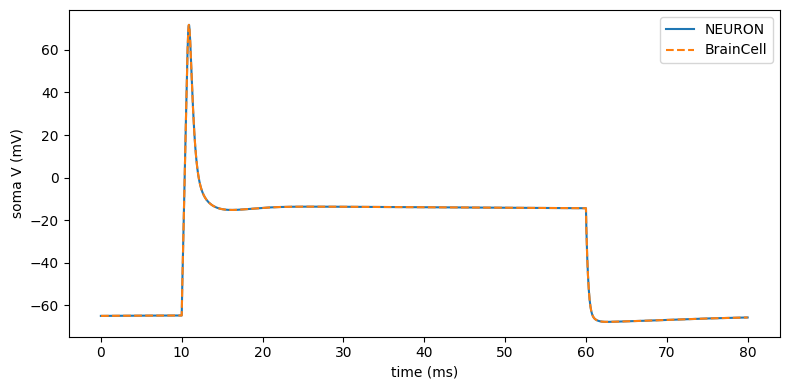

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(t_neuron, nrn_v["soma_voltage_mV"], label="NEURON")
plt.plot(t_bc, bc_v["soma_voltage_mV"], label="BrainCell", linestyle="--")
plt.xlabel("time (ms)")
plt.ylabel("soma V (mV)")
plt.legend()
plt.tight_layout()